# 2D Deep Learning Models for Impact Echo Classification

This notebook implements the GoogLeNet (Inception v1) Convolutional Neural Network.

## GoogLeNet (Transfer Learning)
GoogLeNet uses complex Inception modules to process images at multiple scales simultaneously. 
We use Transfer Learning by loading weights pre-trained on ImageNet, freezing the deep feature 
extractors, and modifying the final fully connected (`fc`) layer for our 2-class problem.

* **Architecture:** GoogLeNet / Inception v1 (Pre-trained `IMAGENET1K_V1` weights)
* **Input Size:** 224 x 224 x 3 (Note: Different from AlexNet's 227x227)
* **Optimizer:** SGDM
* **Batch Size:** 50
* **Max Epochs:** 60
* **Learning Rate:** 1e-4

In [2]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from sklearn.metrics import confusion_matrix

from sklearn.metrics import confusion_matrix

# Hardware setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("=== Hardware Check ===")
if device.type == 'cuda':
    print(f"SUCCESS: GPU Detected - {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True 
else:
    print("WARNING: CUDA not detected by PyTorch.")
print("======================\n")

c:\Users\kairen.shen.ctr\.conda\envs\bsm\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


=== Hardware Check ===
SUCCESS: GPU Detected - NVIDIA RTX 5000 Ada Generation Laptop GPU



In [3]:
base_dir = r"C:\Users\kairen.shen.ctr\My Drive\4 IE reproduce\testing data"

all_filepaths = []
all_labels = []
all_slab_ids = []

for slab_id in range(1, 9):
    slab_folder = os.path.join(base_dir, f"Slab{slab_id}")
    
    # Process Defected (Class 1)
    d_folder = os.path.join(slab_folder, "D")
    if os.path.exists(d_folder):
        for file in os.listdir(d_folder):
            if file.endswith(".txt"):
                all_filepaths.append(os.path.join(d_folder, file))
                all_labels.append(1)
                all_slab_ids.append(slab_id)
                
    # Process Sound (Class 0)
    s_folder = os.path.join(slab_folder, "S")
    if os.path.exists(s_folder):
        for file in os.listdir(s_folder):
            if file.endswith(".txt"):
                all_filepaths.append(os.path.join(s_folder, file))
                all_labels.append(0)
                all_slab_ids.append(slab_id)

all_filepaths = np.array(all_filepaths)
all_labels = np.array(all_labels)
all_slab_ids = np.array(all_slab_ids)

print(f"Total files found: {len(all_filepaths)}")
print(f"Total Sound (0): {sum(all_labels == 0)}, Total Defected (1): {sum(all_labels == 1)}")

Total files found: 2016
Total Sound (0): 1504, Total Defected (1): 512


## GoogLeNet Dataset & Model Setup
Notice the resize parameter in the Dataset is now `(224, 224)`. 
We disable `aux_logits` in GoogLeNet (after loading the weights) to bypass the auxiliary training heads and 
focus solely on the final classification layer.

In this setup, the final classifier head itself is built as `FC -> ReLU -> FC -> LogSoftmax`, which exposes four trainable parameter tensors:
`fc1.weight`, `fc1.bias`, `fc2.weight`, and `fc2.bias`.

In [11]:
class SpectrogramDataset(Dataset):
    def __init__(self, file_paths, labels):
        self.file_paths = file_paths
        self.labels = labels
        
        # ImageNet standardization values
        self.normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        df = pd.read_csv(self.file_paths[idx], sep=r'\s+', header=None, names=['Time', 'Voltage'])
        voltage = df['Voltage'].values.astype(np.float32)
        voltage = voltage - np.mean(voltage)
        
        f, t, Zxx = signal.stft(voltage, fs=200000, nperseg=128, noverlap=64)
        spec_mag = np.abs(Zxx)
        spec_log = 10 * np.log10(spec_mag + 1e-8)
        
        spec_norm = (spec_log - np.min(spec_log)) / (np.max(spec_log) - np.min(spec_log) + 1e-8)
        
        # CRITICAL Fix for GoogLeNet: Resize to 224x224 instead of 227x227
        spec_tensor = torch.tensor(spec_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
        resized_spec = F.interpolate(spec_tensor, size=(224, 224), mode='bilinear', align_corners=False)
        
        rgb_spec = resized_spec.squeeze(0).repeat(3, 1, 1)
        final_spec = self.normalize(rgb_spec)
        
        label_tensor = torch.tensor(self.labels[idx], dtype=torch.long)
        return final_spec, label_tensor

class GoogLeNetTransferHead(nn.Module):
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(in_features, 512)
        self.relu = nn.ReLU(inplace=True)
        self.fc2 = nn.Linear(512, num_classes)

        nn.init.kaiming_normal_(self.fc1.weight, mode='fan_out', nonlinearity='relu')
        nn.init.constant_(self.fc1.bias, 0)
        nn.init.xavier_normal_(self.fc2.weight)
        nn.init.constant_(self.fc2.bias, 0)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x


def get_googlenet_tl(num_classes=2):
    # Load pre-trained GoogLeNet with aux_logits=True because the weights require it.
    model = models.googlenet(weights=models.GoogLeNet_Weights.IMAGENET1K_V1, aux_logits=True)

    # Remove auxiliary heads to focus on the final classifier only
    model.aux_logits = False
    if hasattr(model, 'aux1'):
        model.aux1 = None
    if hasattr(model, 'aux2'):
        model.aux2 = None

    # Freeze all pretrained parameters first
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze the last inception blocks (inception5a, inception5b)
    if hasattr(model, 'inception5a'):
        for param in model.inception5a.parameters():
            param.requires_grad = True
    if hasattr(model, 'inception5b'):
        for param in model.inception5b.parameters():
            param.requires_grad = True

    # Replace the final classifier head with an explicit transfer-learning block
    num_ftrs = model.fc.in_features
    model.fc = GoogLeNetTransferHead(num_ftrs, num_classes)
    for param in model.fc.parameters():
        param.requires_grad = True

    return model


def print_trainable_parameters(model):
    trainable = [(name, tuple(param.shape)) for name, param in model.named_parameters() if param.requires_grad]
    print(f"Trainable parameters ({len(trainable)} tensors):")
    for name, shape in trainable:
        print(f"  {name}: {shape}")
    print(f"Total trainable params: {sum(param.numel() for name, param in model.named_parameters() if param.requires_grad)}")

In [ ]:
# 3. Training Protocol (GoogLeNet TL)
# =========================================================
# Hyperparameters from Table 3 for GoogLeNet (TL)
EPOCHS = 60
BATCH_SIZE = 50
LR = 3e-4 # it is better than 1e-4 for GoogLeNet TL, as per Table 3
MOMENTUM = 0.9

# Keep results reproducible
torch.manual_seed(42)
np.random.seed(42)

googlenet_tl_metrics = {'ACC': [], 'TPR': [], 'TNR': [], 'F1': []}
iteration_accuracies = {slab: [] for slab in range(1, 9)}
total_start_time = time.time()

for test_slab in range(1, 9):
    print(f"--- Training GoogLeNet (TL): Holding out Slab {test_slab} for Testing ---")
    fold_start_time = time.time()
    
    # Split data (Leave-One-Specimen-Out)
    train_idx = np.where(all_slab_ids != test_slab)[0]
    test_idx = np.where(all_slab_ids == test_slab)[0]
    
    # Define files and labels
    train_files, train_labels = all_filepaths[train_idx], all_labels[train_idx]
    test_files, test_labels = all_filepaths[test_idx], all_labels[test_idx]
    
    train_dataset = SpectrogramDataset(train_files, train_labels)
    test_dataset = SpectrogramDataset(test_files, test_labels)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
    
    # Initialize Model
    model = get_googlenet_tl().to(device)
    
    # Dynamic Class Weighting to handle the Sound vs Defected imbalance (~3:1)
    num_sound = int(np.sum(train_labels == 0))
    num_defected = int(np.sum(train_labels == 1))
    if num_defected == 0:
        class_weights = torch.tensor([1.0, 1.0], dtype=torch.float32, device=device)
    else:
        weight_ratio = num_sound / num_defected
        class_weights = torch.tensor([1.0, weight_ratio], dtype=torch.float32, device=device)
    
    # Use CrossEntropyLoss for raw logits output (model.fc returns logits)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    
    # Pass only the unfrozen parameters to the optimizer
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.SGD(
        trainable_params,
        lr=LR,
        momentum=MOMENTUM,
        weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )
    
    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        
        for inputs, targets in train_loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            
            optimizer.zero_grad(set_to_none=True)
            outputs = model(inputs)
            if isinstance(outputs, tuple):
                outputs = outputs[0]
            
            loss = criterion(outputs, targets)
            loss.backward()
            
            # Gradient clipping as a safety net
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            running_loss += loss.detach().item()

            # Calculate and store batch accuracy for the Iteration Plot
            _, preds = torch.max(outputs, 1)
            correct = (preds == targets).sum().item()
            batch_acc = (correct / targets.size(0)) * 100.0
            iteration_accuracies[test_slab].append(batch_acc)
            
        epoch_loss = running_loss / max(1, len(train_loader))
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  Epoch [{epoch+1:02d}/{EPOCHS}] - Loss: {epoch_loss:.4f}")
        scheduler.step(epoch_loss)
            
    # Evaluation
    model.eval()
    all_preds = []
    all_targs = []
    
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            outputs = model(inputs)
            if isinstance(outputs, tuple):
                outputs = outputs[0]
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targs.extend(targets.cpu().numpy())
            
    if len(np.unique(all_targs)) < 2:
        tn = fp = fn = tp = 0
    else:
        tn, fp, fn, tp = confusion_matrix(all_targs, all_preds, labels=[0, 1]).ravel()

    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0  
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0.0  
    acc = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0           
    f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0 
    
    fold_time = time.time() - fold_start_time
    print(f"  > Test Slab {test_slab} Results - ACC: {acc:.2f} | TPR: {tpr:.2f} | TNR: {tnr:.2f} | F1: {f1:.2f}")
    print(f"  > Fold completed in {fold_time:.1f} seconds.\n")
    
    googlenet_tl_metrics['ACC'].append(acc)
    googlenet_tl_metrics['TPR'].append(tpr)
    googlenet_tl_metrics['TNR'].append(tnr)
    googlenet_tl_metrics['F1'].append(f1)

total_time = time.time() - total_start_time

# 4. Output Summary Metrics
# =========================================================
print("=============================================")
print(f"Total GoogLeNet (TL) Training Time: {total_time/60:.2f} minutes")
print("=== Overall GoogLeNet (TL) Performance Metrics ===")

for metric, values in googlenet_tl_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    cov_val = std_val / mean_val if mean_val > 0 else 0.0
    max_val = np.max(values)
    min_val = np.min(values)
    print(f"{metric} - Mean: {mean_val:.2f} | COV: {cov_val:.2f} | Max: {max_val:.2f} | Min: {min_val:.2f}")

--- Training GoogLeNet (TL): Holding out Slab 1 for Testing ---


C:\Users\kairen.shen.ctr\AppData\Roaming\Python\Python39\site-packages\torchvision\models\googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(


  Epoch [01/60] - Loss: 0.7506
  Epoch [10/60] - Loss: 0.5416
  Epoch [20/60] - Loss: 0.4219
  Epoch [30/60] - Loss: 0.2865
  Epoch [40/60] - Loss: 0.1849
  Epoch [50/60] - Loss: 0.1061
  Epoch [60/60] - Loss: 0.0596
  > Test Slab 1 Results - ACC: 0.85 | TPR: 0.50 | TNR: 0.97 | F1: 0.63
  > Fold completed in 380.2 seconds.

--- Training GoogLeNet (TL): Holding out Slab 2 for Testing ---


C:\Users\kairen.shen.ctr\AppData\Roaming\Python\Python39\site-packages\torchvision\models\googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(


  Epoch [01/60] - Loss: 0.7906
  Epoch [10/60] - Loss: 0.5366
  Epoch [20/60] - Loss: 0.3843
  Epoch [30/60] - Loss: 0.2664
  Epoch [40/60] - Loss: 0.1734
  Epoch [50/60] - Loss: 0.1078
  Epoch [60/60] - Loss: 0.0670
  > Test Slab 2 Results - ACC: 0.81 | TPR: 0.70 | TNR: 0.85 | F1: 0.65
  > Fold completed in 380.9 seconds.

--- Training GoogLeNet (TL): Holding out Slab 3 for Testing ---


...

  Epoch [01/60] - Loss: 0.8068
  Epoch [10/60] - Loss: 0.5382
  Epoch [20/60] - Loss: 0.4085
  Epoch [30/60] - Loss: 0.2825
  Epoch [40/60] - Loss: 0.1721
  Epoch [50/60] - Loss: 0.0941
  Epoch [60/60] - Loss: 0.0562
  > Test Slab 6 Results - ACC: 0.78 | TPR: 0.42 | TNR: 0.90 | F1: 0.49
  > Fold completed in 363.9 seconds.

--- Training GoogLeNet (TL): Holding out Slab 7 for Testing ---


C:\Users\kairen.shen.ctr\AppData\Roaming\Python\Python39\site-packages\torchvision\models\googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(


  Epoch [01/60] - Loss: 0.9408
  Epoch [10/60] - Loss: 0.5321
  Epoch [20/60] - Loss: 0.3874
  Epoch [30/60] - Loss: 0.2493
  Epoch [40/60] - Loss: 0.1342
  Epoch [50/60] - Loss: 0.0840
  Epoch [60/60] - Loss: 0.0404
  > Test Slab 7 Results - ACC: 0.78 | TPR: 0.41 | TNR: 0.90 | F1: 0.48
  > Fold completed in 371.9 seconds.

--- Training GoogLeNet (TL): Holding out Slab 8 for Testing ---


C:\Users\kairen.shen.ctr\AppData\Roaming\Python\Python39\site-packages\torchvision\models\googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(


  Epoch [01/60] - Loss: 0.7406
  Epoch [10/60] - Loss: 0.5403
  Epoch [20/60] - Loss: 0.4058
  Epoch [30/60] - Loss: 0.2645
  Epoch [40/60] - Loss: 0.1590
  Epoch [50/60] - Loss: 0.0825
  Epoch [60/60] - Loss: 0.0511
  > Test Slab 8 Results - ACC: 0.75 | TPR: 0.58 | TNR: 0.81 | F1: 0.54
  > Fold completed in 360.7 seconds.

Total GoogLeNet (TL) Training Time: 50.58 minutes
=== Overall GoogLeNet (TL) Performance Metrics ===
ACC - Mean: 0.77 | COV: 0.06 | Max: 0.85 | Min: 0.67
TPR - Mean: 0.56 | COV: 0.18 | Max: 0.70 | Min: 0.41
TNR - Mean: 0.84 | COV: 0.09 | Max: 0.97 | Min: 0.69
F1 - Mean: 0.55 | COV: 0.11 | Max: 0.65 | Min: 0.48



Generating Accuracy vs Iteration plot for GoogLeNet (TL)...


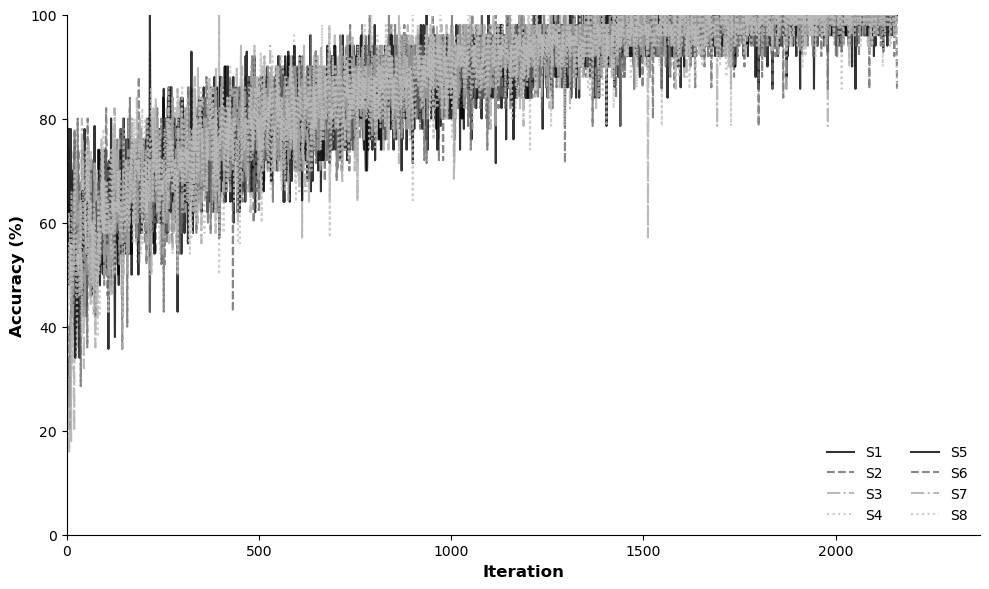

Plot saved successfully as 'googlenet_tl_accuracy_vs_iteration.png'.


In [13]:
# =========================================================
# 5. Plotting Accuracy vs Iteration
# =========================================================
print("\nGenerating Accuracy vs Iteration plot for GoogLeNet (TL)...")
fig, ax = plt.subplots(figsize=(10, 6))

line_styles = ['-', '--', '-.', ':', '-', '--', '-.', ':']
colors = ['black', 'dimgray', 'darkgray', 'silver', 'black', 'dimgray', 'darkgray', 'silver']

for slab_id in range(1, 9):
    acc_data = iteration_accuracies[slab_id]
    iterations = range(1, len(acc_data) + 1)
    
    ax.plot(iterations, acc_data, label=f'S{slab_id}', 
             linestyle=line_styles[slab_id-1], color=colors[slab_id-1], alpha=0.8, linewidth=1.5)

ax.set_xlabel('Iteration', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_ylim(0, 100)

# Add some padding to the x-axis for the legend to breathe
ax.set_xlim(0, len(iteration_accuracies[1]) * 1.1) 

# Clean up axes for a publication-ready look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(loc='lower right', frameon=False, fontsize=10, ncol=2)

plt.tight_layout()
plt.savefig('googlenet_tl_accuracy_vs_iteration.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot saved successfully as 'googlenet_tl_accuracy_vs_iteration.png'.")